In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [36]:
df = pd.read_csv(
    "/content/HHS_Unaccompanied_Alien_Children_Program.csv"
)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [37]:
print(df.shape)

(1170, 6)


In [38]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df = df.sort_values("Date")

In [39]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

In [40]:
df = df.dropna(
    subset=[
        "Date",
        "Children apprehended and placed in CBP custody*",
        "Children in CBP custody",
        "Children transferred out of CBP custody",
        "Children discharged from HHS Care"
    ]
)

print(df.shape)

(720, 6)


In [41]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .fillna(method="ffill")
)

df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .astype(int)
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 39.4 KB


/tmp/ipykernel_8386/2945262993.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


In [42]:
# Total System Load

df["Total_System_Load"] = (
    df["Children in CBP custody"]
    +
    df["Children in HHS Care"]
)

# Net Intake Pressure

df["Net_Intake_Pressure"] = (
    df["Children transferred out of CBP custody"]
    -
    df["Children discharged from HHS Care"]
)

# Care Load Growth Rate

df["Care_Load_Growth_Rate"] = (
    df["Total_System_Load"]
    .pct_change()
    * 100
)

# Backlog Accumulation

df["Backlog_Accumulation"] = (
    df["Net_Intake_Pressure"]
    .cumsum()
)

# Discharge Offset Ratio

df["Discharge_Offset_Ratio"] = (
    df["Children discharged from HHS Care"]
    /
    (
        df["Children transferred out of CBP custody"]
        + 1
    )
)

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total_System_Load,Net_Intake_Pressure,Care_Load_Growth_Rate,Backlog_Accumulation,Discharge_Offset_Ratio
719,2023-01-12,33.0,53.0,34.0,6566,436.0,6619.0,-402.0,NaN,-402.0,12.457143
718,2023-01-22,32.0,49.0,39.0,7122,227.0,7171.0,-188.0,8.339628,-590.0,5.675000
717,2023-01-23,32.0,50.0,39.0,7280,181.0,7330.0,-142.0,2.217264,-732.0,4.525000
716,2023-01-24,47.0,42.0,47.0,7433,175.0,7475.0,-128.0,1.978172,-860.0,3.645833
715,2023-01-25,20.0,22.0,41.0,7538,180.0,7560.0,-139.0,1.137124,-999.0,4.285714


In [43]:
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total_System_Load,Net_Intake_Pressure,Care_Load_Growth_Rate,Backlog_Accumulation,Discharge_Offset_Ratio
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,719.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944,6232.769444,-44.738889,-0.116894,-25888.534722,1.927201
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000,2002.000000,-465.000000,-11.601513,-33908.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000,2500.750000,-94.250000,-0.689345,-32173.750000,0.842155
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000,6633.500000,-11.500000,0.123877,-31494.000000,1.222222
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000,8249.500000,5.250000,0.858314,-20965.750000,2.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000,11762.000000,206.000000,8.339628,-402.000000,39.666667
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841,2918.458078,95.863856,1.895490,9665.680327,2.877663


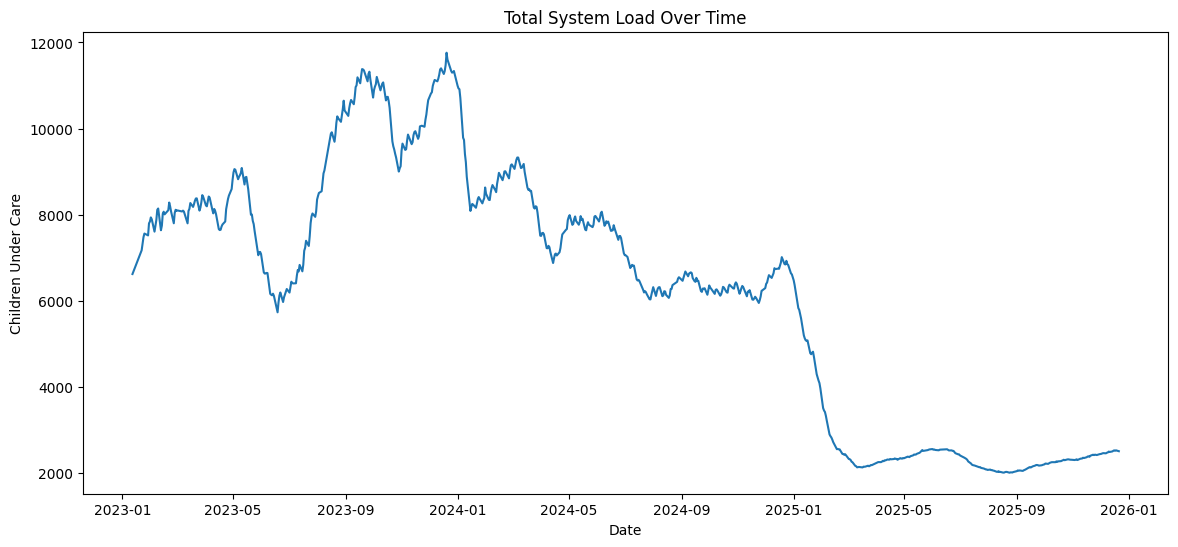

In [44]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Total_System_Load"]
)

plt.title(
    "Total System Load Over Time"
)

plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.show()

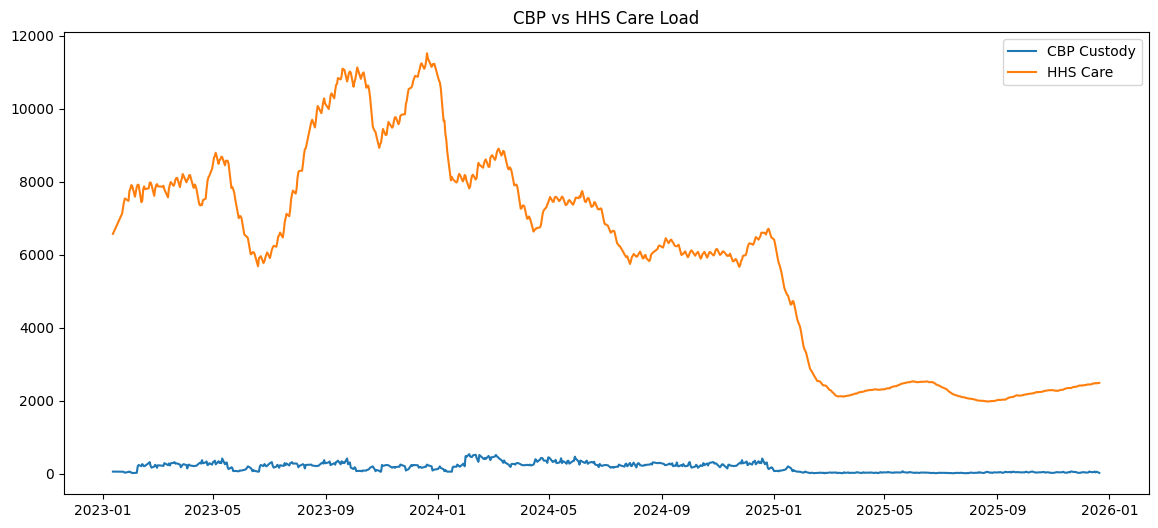

In [45]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="CBP Custody"
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="HHS Care"
)

plt.legend()

plt.title(
    "CBP vs HHS Care Load"
)

plt.show()

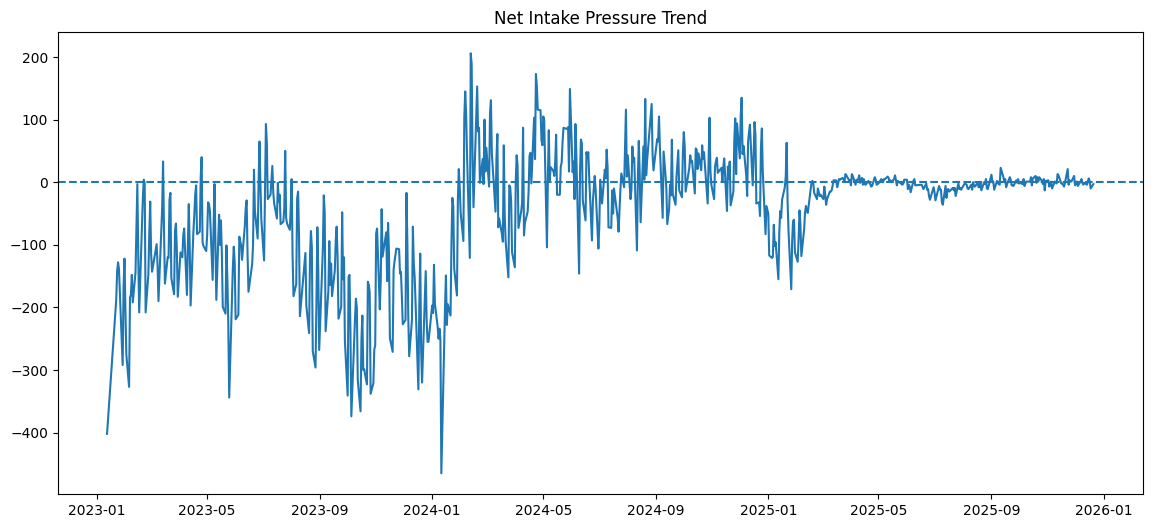

In [46]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Net_Intake_Pressure"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Net Intake Pressure Trend"
)

plt.show()

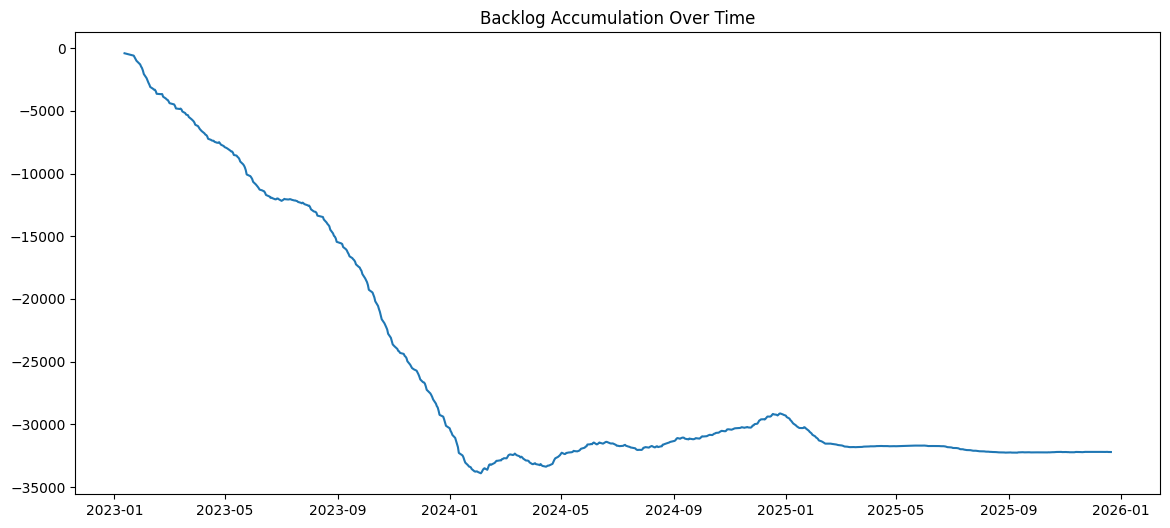

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Backlog_Accumulation"]
)

plt.title(
    "Backlog Accumulation Over Time"
)

plt.show()

In [48]:
df["Load_7_Day_Avg"] = (
    df["Total_System_Load"]
    .rolling(7)
    .mean()
)

df["Load_14_Day_Avg"] = (
    df["Total_System_Load"]
    .rolling(14)
    .mean()
)

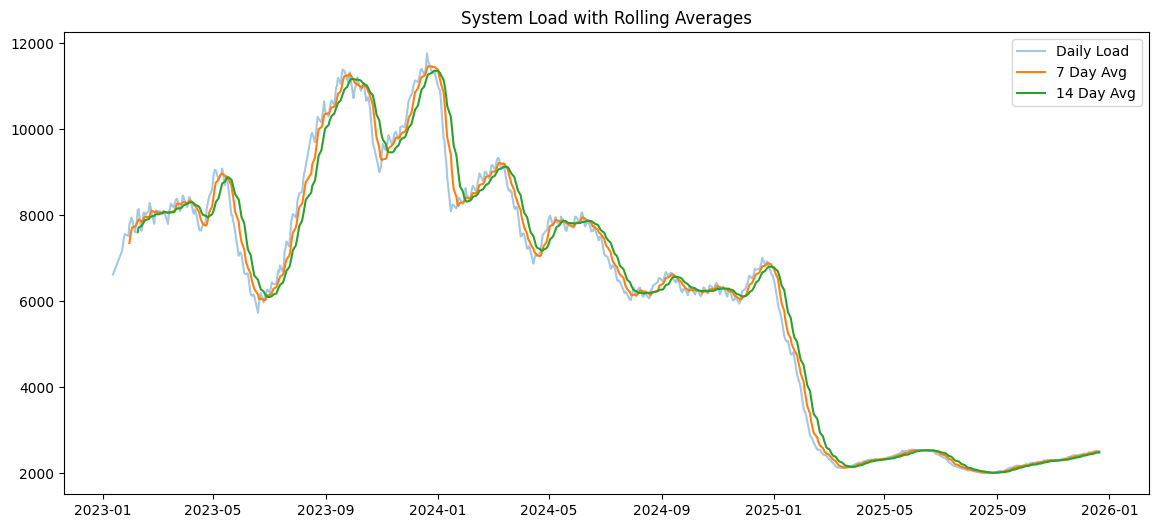

In [49]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Total_System_Load"],
    alpha=0.4,
    label="Daily Load"
)

plt.plot(
    df["Date"],
    df["Load_7_Day_Avg"],
    label="7 Day Avg"
)

plt.plot(
    df["Date"],
    df["Load_14_Day_Avg"],
    label="14 Day Avg"
)

plt.legend()

plt.title(
    "System Load with Rolling Averages"
)

plt.show()

In [50]:
print(
    "Average Total System Load:",
    round(df["Total_System_Load"].mean(),2)
)

print(
    "Average Net Intake Pressure:",
    round(df["Net_Intake_Pressure"].mean(),2)
)

print(
    "Average Growth Rate:",
    round(df["Care_Load_Growth_Rate"].mean(),2)
)

print(
    "Average Discharge Offset Ratio:",
    round(df["Discharge_Offset_Ratio"].mean(),2)
)

Average Total System Load: 6232.77
Average Net Intake Pressure: -44.74
Average Growth Rate: -0.12
Average Discharge Offset Ratio: 1.93


In [51]:
df.to_csv(
    "processed_uac_data.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


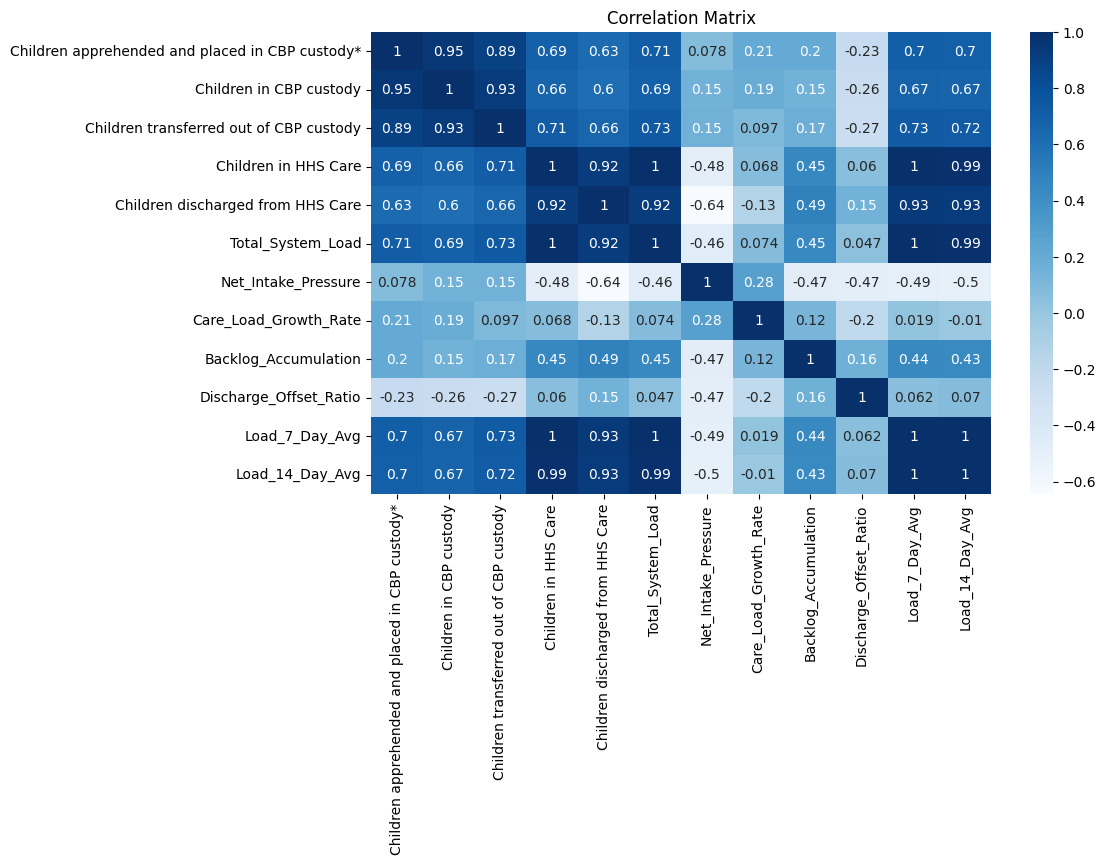

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

/tmp/ipykernel_8386/860179657.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


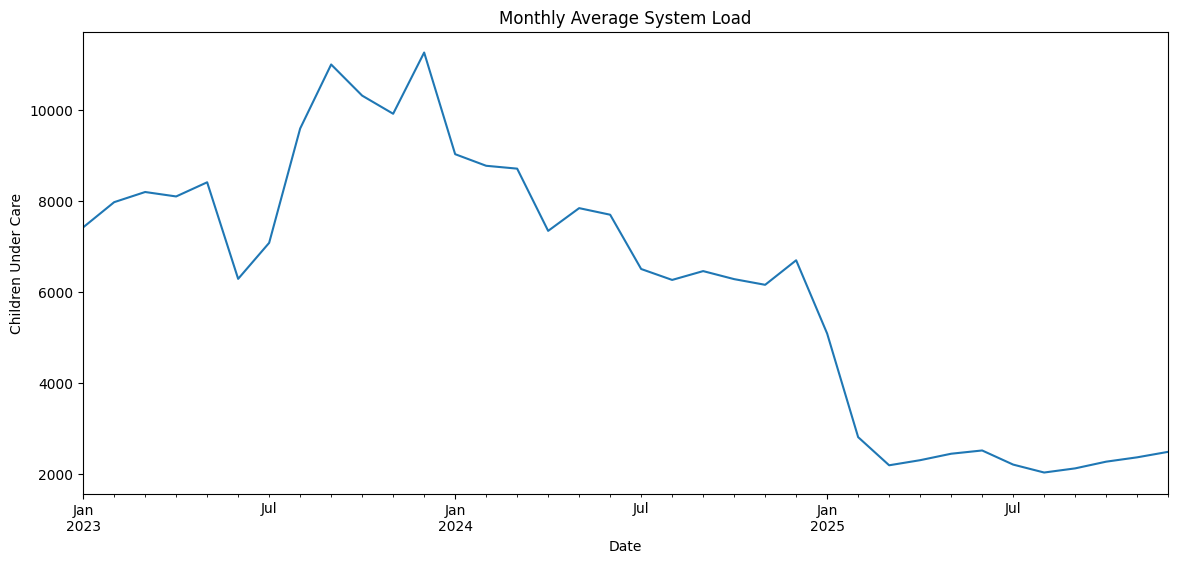

In [53]:
monthly_load = (
    df
    .set_index("Date")
    .resample("M")
    ["Total_System_Load"]
    .mean()
)

plt.figure(figsize=(14,6))

monthly_load.plot()

plt.title(
    "Monthly Average System Load"
)

plt.ylabel(
    "Children Under Care"
)

plt.show()

In [54]:
volatility_index = (
    df["Total_System_Load"]
    .std()
)

print(
    "Care Load Volatility Index:",
    round(volatility_index,2)
)

Care Load Volatility Index: 2918.46


In [55]:
kpi_summary = pd.DataFrame({

    "KPI":[
        "Average System Load",
        "Average Net Intake",
        "Average Growth Rate",
        "Discharge Offset Ratio",
        "Volatility Index"
    ],

    "Value":[
        round(df["Total_System_Load"].mean(),2),
        round(df["Net_Intake_Pressure"].mean(),2),
        round(df["Care_Load_Growth_Rate"].mean(),2),
        round(df["Discharge_Offset_Ratio"].mean(),2),
        round(volatility_index,2)
    ]
})

kpi_summary

,KPI,Value
0,Average System Load,6232.77
1,Average Net Intake,-44.74
2,Average Growth Rate,-0.12
3,Discharge Offset Ratio,1.93
4,Volatility Index,2918.46
